# 01 — Exploratory Data Analysis

**Goal:** explore relationships in the cleaned dataset to surface patterns useful for feature
engineering and modeling (Assignment Tasks 7-9).

- **Input:** `data/processed/grid_load_clean.csv` (produced by `00_data_understanding.ipynb`)
- **Output:** charts saved to `reports/figures/`


In [1]:
# Same sys.path trick as 00_data_understanding.ipynb so `src/` imports work from this notebook.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loading import load_dataset

sns.set_theme(style="whitegrid")
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Reuses load_dataset() from src/data_loading.py — it's just a thin, safe pd.read_csv, and
# the cleaned file has no dirty values left, so no extra handling is needed here.
df = load_dataset(PROJECT_ROOT / "data" / "processed" / "grid_load_clean.csv")
print(f"shape: {df.shape}")
df.head()


shape: (1480, 11)


,Record_ID,Region,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW
0,1,Central,20.0,0,26.7,52.0,3.1,93.0,89.0,0.03,850.3
1,2,Eastern,13.0,0,18.5,63.0,3.7,95.0,89.0,0.38,788.3
2,3,Western,14.0,4,22.7,90.0,3.3,71.0,55.0,0.13,548.0
3,4,Northern,10.0,0,19.6,41.0,0.1,75.0,78.0,0.45,604.6
4,5,Northern,12.0,0,27.4,88.0,0.0,86.0,58.0,0.70,546.1


In [3]:
df.describe()


,Record_ID,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000
mean,740.500000,11.928378,3.044595,26.528446,64.066892,4.088919,75.145946,57.867568,0.246128,616.404730
std,427.383512,7.055580,2.004568,4.975564,17.544349,3.955751,14.549779,21.754983,0.220603,102.568372
min,1.000000,0.000000,0.000000,18.000000,35.000000,0.000000,50.000000,20.000000,0.000000,369.500000
25%,370.750000,6.000000,1.000000,22.100000,49.000000,0.000000,63.000000,39.000000,0.070000,538.900000
50%,740.500000,12.000000,3.000000,26.700000,63.000000,3.300000,75.000000,58.000000,0.180000,617.300000
75%,1110.250000,18.000000,5.000000,30.900000,79.000000,6.900000,87.250000,77.000000,0.370000,692.575000
max,1480.000000,23.000000,6.000000,35.000000,95.000000,18.400000,100.000000,95.000000,1.800000,900.000000


## Task 7 — Key variables for visualization

- **Target:** `GridLoad_MW` — what every other chart in this notebook is ultimately compared
  against.
- **Numeric predictors:** `Temperature_C`, `Humidity_pct`, `Rainfall_mm`, `PopulationIndex`,
  `IndustrialIndex`, `SolarGenerationIndex` — plausible physical/demand drivers of load.
- **Time/categorical context:** `Hour`, `DayOfWeek`, `Region` — capture demand cycles and
  geographic differences rather than a continuous physical quantity.


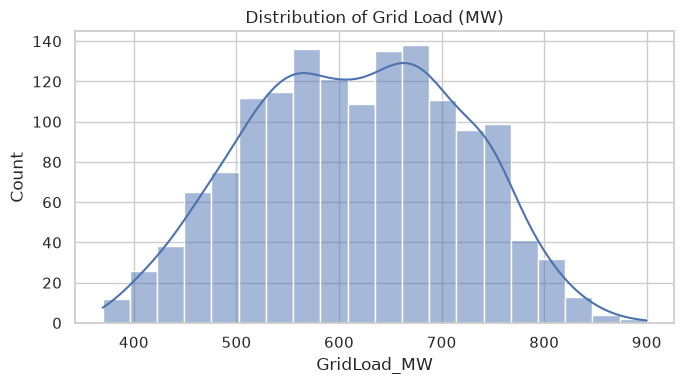

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["GridLoad_MW"], kde=True, ax=ax)
ax.set_title("Distribution of Grid Load (MW)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()


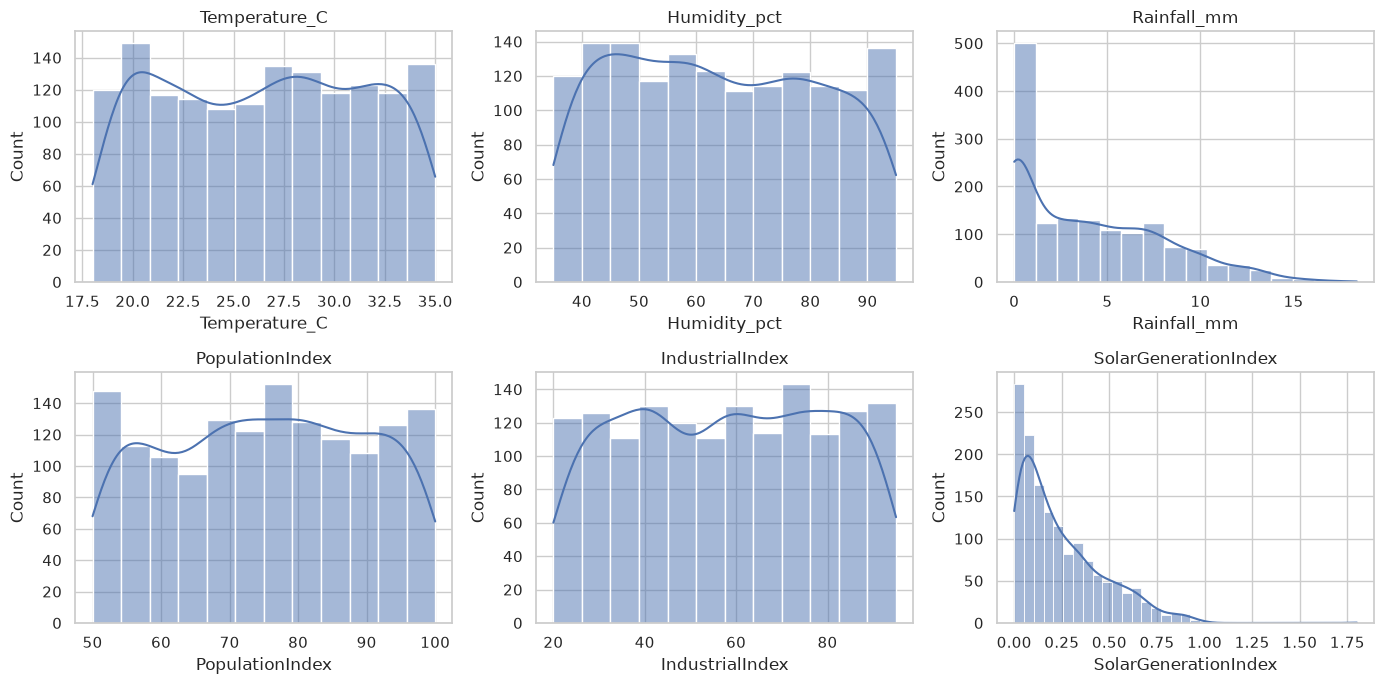

In [5]:
numeric_predictors = [
    "Temperature_C", "Humidity_pct", "Rainfall_mm",
    "PopulationIndex", "IndustrialIndex", "SolarGenerationIndex",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), numeric_predictors):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "predictor_distributions.png", dpi=150)
plt.show()


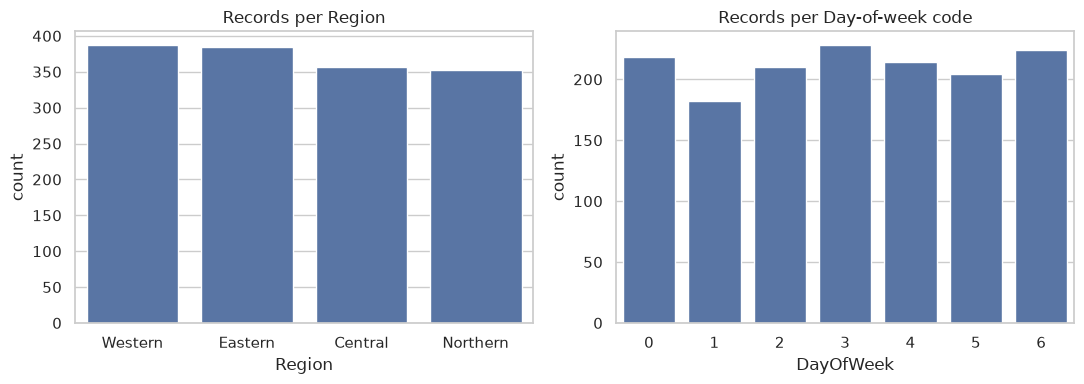

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Region", data=df, order=df["Region"].value_counts().index, ax=axes[0])
axes[0].set_title("Records per Region")
sns.countplot(x="DayOfWeek", data=df, ax=axes[1])
axes[1].set_title("Records per Day-of-week code")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "categorical_counts.png", dpi=150)
plt.show()


## Task 8 — Visualizations (Matplotlib / Seaborn / Plotly)

### Correlation heatmap

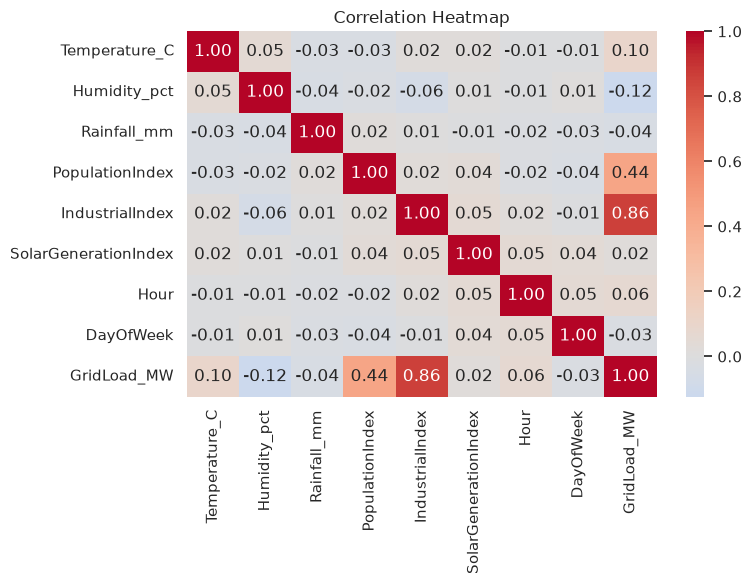

In [7]:
numeric_cols = numeric_predictors + ["Hour", "DayOfWeek", "GridLoad_MW"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150)
plt.show()


In [8]:
# Which features correlate most strongly (either direction) with the target — a first,
# cheap signal for what's likely to matter in modeling and feature engineering.
corr["GridLoad_MW"].drop("GridLoad_MW").sort_values(key=abs, ascending=False)


IndustrialIndex         0.860577
PopulationIndex         0.443357
Humidity_pct           -0.124772
Temperature_C           0.101566
Hour                    0.064501
Rainfall_mm            -0.037403
DayOfWeek              -0.028057
SolarGenerationIndex    0.016326
Name: GridLoad_MW, dtype: float64

### Grid load vs Hour / Day of week (demand cycle)

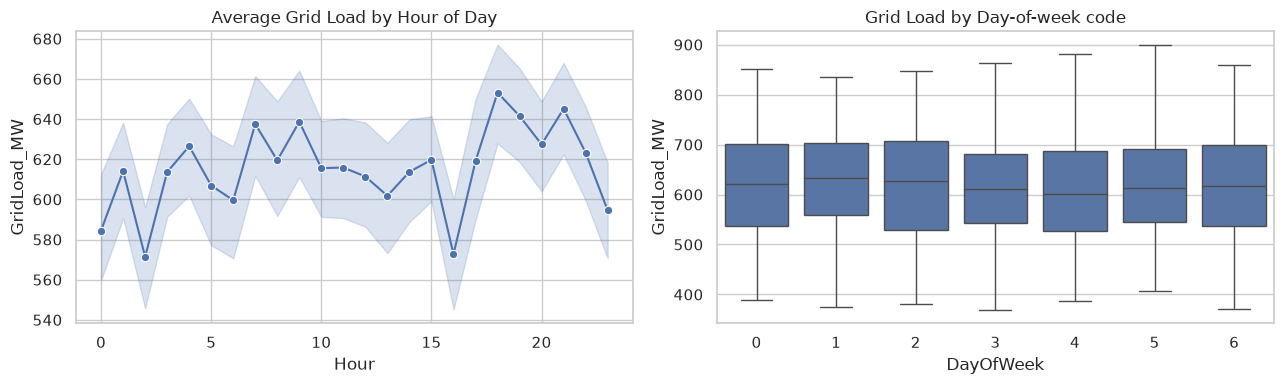

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(x="Hour", y="GridLoad_MW", data=df, marker="o", ax=axes[0])
axes[0].set_title("Average Grid Load by Hour of Day")
sns.boxplot(x="DayOfWeek", y="GridLoad_MW", data=df, ax=axes[1])
axes[1].set_title("Grid Load by Day-of-week code")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "load_by_hour_and_day.png", dpi=150)
plt.show()


### Grid load by Region

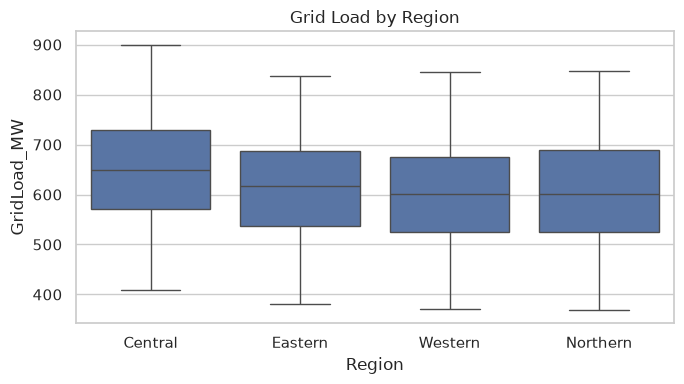

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x="Region", y="GridLoad_MW", data=df, ax=ax)
ax.set_title("Grid Load by Region")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "load_by_region.png", dpi=150)
plt.show()


### Temperature vs Grid Load

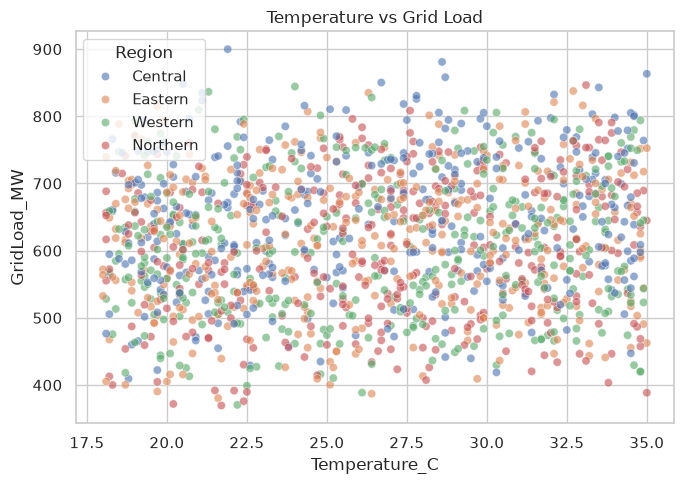

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x="Temperature_C", y="GridLoad_MW", hue="Region", data=df, alpha=0.6, ax=ax)
ax.set_title("Temperature vs Grid Load")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "temperature_vs_load.png", dpi=150)
plt.show()


### Interactive Plotly views

In [12]:
fig = px.scatter(
    df, x="IndustrialIndex", y="GridLoad_MW", color="Region",
    hover_data=["Hour", "DayOfWeek", "Temperature_C"],
    title="Industrial Index vs Grid Load (interactive)",
)
fig.write_html(FIGURES_DIR / "industrial_index_vs_load.html")
fig.show()


In [13]:
# Task 8 explicitly calls for a 3D plot: Temperature, Hour, and Grid Load together.
fig3d = px.scatter_3d(
    df, x="Temperature_C", y="Hour", z="GridLoad_MW", color="Region",
    opacity=0.6, title="Temperature, Hour, and Grid Load (3D)",
)
fig3d.write_html(FIGURES_DIR / "temp_hour_load_3d.html")
fig3d.show()


## Task 9 — Interpreting the visualizations

- **`IndustrialIndex` is by far the strongest linear driver of load** (r = 0.86) — visibly a
  near-straight line in the correlation heatmap and the industrial-index scatter plot.
  `PopulationIndex` is a distant second (r = 0.44); every other numeric predictor
  (`Temperature_C`, `Humidity_pct`, `Rainfall_mm`, `SolarGenerationIndex`) has |r| < 0.13 —
  weak on their own.
- **`Hour` barely correlates linearly with load (r = 0.06), but the hour line plot shows a
  real, non-linear daily cycle**: average load peaks in the evening (highest around hour 18,
  then 21, 19) and troughs overnight (lowest around hour 2), with roughly an 82 MW swing
  between the highest- and lowest-average hours — about 80% of the dataset's overall standard
  deviation (102 MW). The weak *linear* correlation despite that real swing is exactly why a
  cyclical (sin/cos) encoding of `Hour`, not the raw 0-23 number, was flagged as a feature
  candidate in `00_data_understanding.ipynb` — a linear model can't otherwise "see" that hour
  23 and hour 0 are adjacent.
- **`DayOfWeek` shows almost no effect** — every day's average load sits within about 18 MW of
  the others (610-628 MW) — much flatter than the hour-of-day swing. Weekday/weekend isn't a
  useful signal here.
- **`Region` shows a modest, real difference**: Central averages ~648 MW vs. ~603-612 MW for
  the other three regions — worth keeping as a categorical feature, but it's a smaller effect
  than `IndustrialIndex` or `PopulationIndex`.
- **Practical takeaway for modeling:** `IndustrialIndex` and `PopulationIndex` look like the
  two features to prioritize, `Hour` matters but needs cyclical encoding to be useful to linear
  models (tree-based models can pick up the cycle from the raw value directly),`Region` is a
  smaller but real categorical effect, and `DayOfWeek`, `Rainfall_mm`, and
  `SolarGenerationIndex` are the weakest candidates on this evidence alone.


## Handoff notes

- Findings above should inform `notebooks/experiments/feature_engineering_*` and the model choices in `docs/workflow.md` §7.
- Log this EDA pass in `experiment_log.md`.